In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xclim as xc

from unseen import array_handling
from unseen import time_utils

### Read spatially averaged daily mean surface wind speed data files

In [2]:
model_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_CanESM5-dcppA-hindcast_196101-201701_MJJ_nem-2030.nc'
obs_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1979-2025_MJJ_nem-2030.nc'

In [3]:
ds_model = xr.open_dataset(model_infile)
ds_model = ds_model.compute()

In [4]:
ds_model

<xarray.Dataset> Size: 9MB
Dimensions:    (init_date: 57, ensemble: 20, lead_time: 920)
Coordinates:
  * ensemble   (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * lead_time  (lead_time) int64 7kB 0 1 2 3 4 5 6 ... 914 915 916 917 918 919
  * init_date  (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 00:...
    time       (lead_time, init_date) object 420kB 1961-05-01 12:00:00 ... 20...
Data variables:
    sfcWind    (init_date, ensemble, lead_time) float64 8MB 3.944 3.93 ... 4.78
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/06d13276-8392-455a-90a3-8583122...
    variable_id:                 sfcWind
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [5]:
#ds_obs = xr.open_dataset(obs_infile)
#ds_obs = ds_obs.compute()

In [6]:
#ds_obs

In [7]:
sfcWind_model_data = ds_model['sfcWind'].stack({'sample': ['ensemble', 'init_date', 'lead_time']}).values

In [8]:
#sfcWind_obs_data = ds_obs['sfcWind'].values

### Calculate 10th percentile

In [9]:
pctl10 = np.percentile(sfcWind_model_data, 10)

In [10]:
print(pctl10)

3.536619275782543


In [11]:
bins = np.arange(0, 9.5, 0.5)

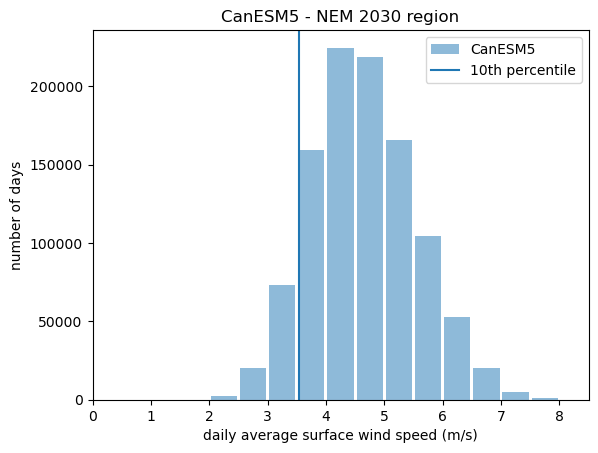

In [12]:
plt.hist(sfcWind_model_data, bins=bins, rwidth=0.9, label='CanESM5', color='tab:blue', alpha=0.5)
#plt.hist(sfcWind_obs_data, bins=bins, rwidth=0.9, label='BARRA-R2', alpha=0.5)
plt.axvline(pctl10, color='tab:blue', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('number of days')
plt.title('CanESM5 - NEM 2030 region')
plt.xlim(0, 8.5)
plt.legend()
plt.show()

### Calculate annual maximum wind drought duration (WDDx)

In [13]:
def calc_wddx_timeseries(timeseries, pctl10):
    """Calculate the annual max wind drought duration (WDDx) for a single timeseries"""

    calm_days = timeseries < pctl10
    drought_events = xc.indices.run_length.find_events(calm_days, window=1)
    drought_events = drought_events.assign_coords(
        time=('event', drought_events['event_start'].data)
    ).drop_vars('event_start')
    drought_events = drought_events.swap_dims({'event': 'time'}).dropna('time')
    wddx_da = drought_events['event_length'].resample(time='1YS').max()
    wddx_ds = wddx_da.to_dataset()

    return wddx_ds
    
    
def calc_wddx_forecast(lead_indexed_forecast):
    """Calculate the WDDx timeseries for a single forecast"""

    time_indexed_forecast = lead_indexed_forecast.swap_dims({'lead_time': 'time'})
    wddx_ds = calc_wddx_timeseries(time_indexed_forecast['sfcWind'], pctl10)
    ntimes = len(wddx_ds['time'])
    wddx_ds['lead_time'] = xr.DataArray(np.arange(1, ntimes + 1, 1), dims={'time': wddx_ds['time']})
    wddx_ds = wddx_ds.swap_dims({'time': 'lead_time'})
    wddx_ds = wddx_ds.reset_coords('time')
    wddx_ds = wddx_ds.rename({'time': 'event_time'})
    
    return wddx_ds


def calc_wddx_model(ds_model):
    """Calculate WDDx for a given model"""

    da_sfcWind = array_handling.reindex_forecast(ds_model['sfcWind'])
    time_datetime = np.array(time_utils.cftime_to_str(da_sfcWind.time), dtype='datetime64')
    da_sfcWind = da_sfcWind.assign_coords(time=time_datetime)
    
    ens_list = []
    for ensemble in range(len(ds_model['ensemble'])):
        init_list = []
        for init in range(len(ds_model['init_date'])):
            wddx = calc_wddx_forecast(ds_model.isel({'init_date': init, 'ensemble': ensemble}))
            init_list.append(wddx)
        init_concat = xr.concat(init_list, dim='init_date')
        ens_list.append(init_concat)
    ens_concat = xr.concat(ens_list, dim='ensemble')

    return ens_concat

In [14]:
wddx_model = calc_wddx_model(ds_model)

In [15]:
wddx_model

<xarray.Dataset> Size: 183kB
Dimensions:       (ensemble: 20, init_date: 57, lead_time: 10)
Coordinates:
  * ensemble      (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * init_date     (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 ...
  * lead_time     (lead_time) int64 80B 1 2 3 4 5 6 7 8 9 10
Data variables:
    event_time    (ensemble, init_date, lead_time) object 91kB 1961-01-01 00:...
    event_length  (ensemble, init_date, lead_time) float64 91kB 3.0 2.0 ... 3.0

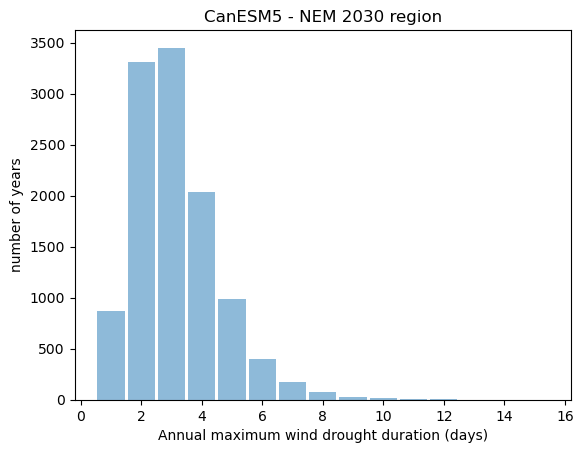

In [16]:
bins = np.arange(0.5, 16.5, 1)
nyears = plt.hist(wddx_model['event_length'].values.flatten(), bins=bins, rwidth=0.9, label='CanESM5', color='tab:blue', alpha=0.5)
plt.xlabel('Annual maximum wind drought duration (days)')
plt.ylabel('number of years')
plt.title('CanESM5 - NEM 2030 region')
#plt.legend()
plt.show()

In [17]:
nyears[0].sum()

np.float64(11360.0)

In [18]:
np.nanmax(wddx_model['event_length'].values)

np.float64(15.0)